In [1]:
from methods import run_gradient_method, nll_regularization_trade_off
import sklearn.datasets
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#import and adjust test data set
X, y = sklearn.datasets.load_breast_cancer(return_X_y=True)
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = 2 * y - 1 #transform y from vector of 0 and 1 to vector of -1 and 1
#add bias to design matrix
X_tilde = np.zeros((X.shape[0], X.shape[1]+1))
for i, x in enumerate(X):
    x = np.append(x, 1)
    X_tilde[i] = x
bias_index = -1 #column in X_tilde that represents bias

In [3]:
#set input variables for gradient method
gamma = 3 #regularization parameter, for standard regression set to 0
theta_start = np.zeros(X_tilde.shape[1])
L = gamma + 0.25 * np.linalg.norm(X_tilde)**2 #Lipschitz constant to determine step size
step_size = 1/L
stop_criterion = 1e-4
max_number_iter = 4000
acceleration = 0.7 #for accelerated gradient method >0, default set to 0

In [4]:
#run gradient method
theta, ob_func_values, gap, converged = run_gradient_method(
    y=y,
    X=X_tilde,
    theta_start=theta_start,
    gamma=gamma,
    step_size=step_size,
    stop_criterion=stop_criterion,
    max_number_iterations=max_number_iter,
    bias_index=bias_index)
print(converged)

False


In [5]:
#run accelerated gradient method
theta_acc, ob_func_values_acc, gap_acc, converged_acc = run_gradient_method(
    y=y,
    X=X_tilde,
    theta_start=theta_start,
    gamma=gamma,
    step_size=step_size,
    stop_criterion=stop_criterion,
    max_number_iterations=max_number_iter,
    acceleration=acceleration,
    bias_index=bias_index)
print(converged_acc)

True


In [6]:
#compute trade-off curve
gamma_values = np.logspace(-3, 3, 20)
current_theta =theta_start #used to warm-start algorithm
trade_off_points = []

for gamma_value in gamma_values:
    L_constant = gamma_value + 0.25 * np.linalg.norm(X_tilde)**2
    current_theta = run_gradient_method(y=y,
                                        X=X_tilde,
                                        theta_start=current_theta,
                                        gamma=gamma_value,
                                        acceleration=acceleration)[0]
    trade_off_points.append(nll_regularization_trade_off(y=y,
                                                         X=X_tilde,
                                                         theta=current_theta))

nll, reg = zip(*trade_off_points)

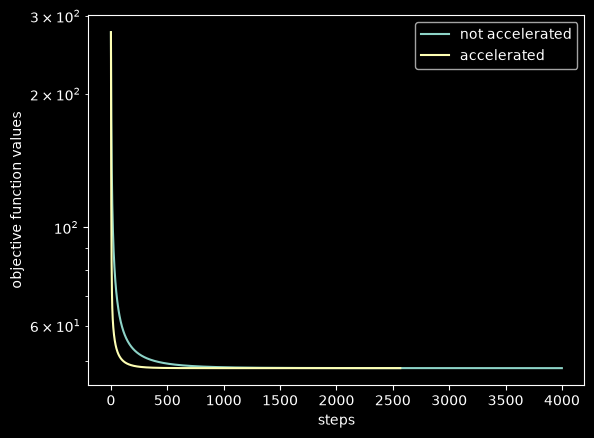

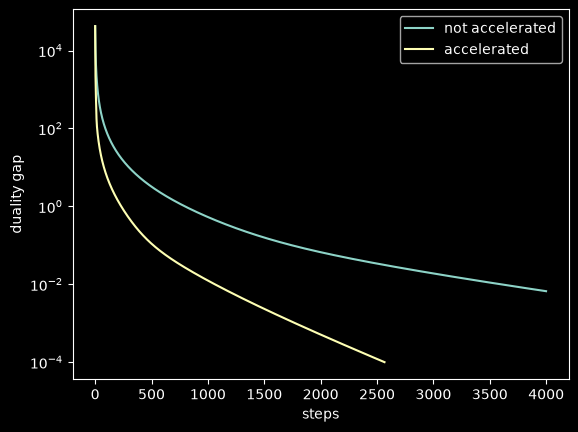

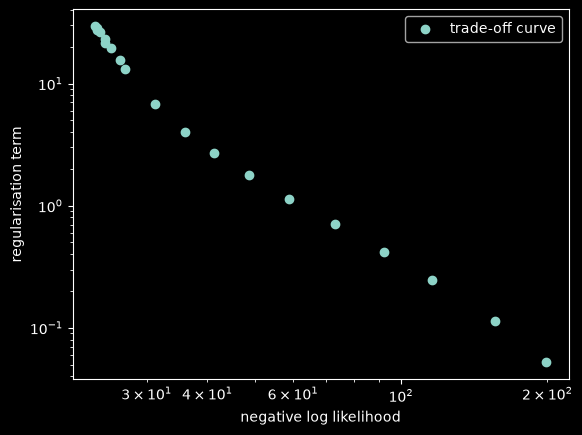

In [7]:
# plots
plt.figure(1)
plt.plot(ob_func_values, label="not accelerated")
plt.plot(ob_func_values_acc, label="accelerated")
plt.yscale("log")
plt.xlabel("steps")
plt.ylabel("objective function values")
plt.legend()
plt.show()

plt.figure(2)
plt.plot(gap, label="not accelerated")
plt.plot(gap_acc, label="accelerated")
plt.yscale("log")
plt.xlabel("steps")
plt.ylabel("duality gap")
plt.legend()
plt.show()

plt.figure(3)
plt.scatter(nll[1:], reg[1:], label="trade-off curve")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("negative log likelihood")
plt.ylabel("regularisation term")
plt.legend()
plt.show()